In [1]:
import os
import re
import math
import random
import zlib
from datetime import datetime
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import rasterio
from rasterio.errors import RasterioIOError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.amp
import matplotlib.pyplot as plt

import json
import numpy as np
import torch
from pathlib import Path

from pathlib import Path
import os, re, zlib, random
import numpy as np
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader

import os
import re
import zlib
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import requests

import rasterio  # needed for .tif


### CONFIG

In [2]:

# ============================================================
# CONFIG
# ============================================================

class Config:
    # ---- data ----
    ROOT = r"D:\Amrita\Final Year Project\fyp 2026\Dataset\data"
    USE_NORMALIZED = True
    INPUT_LEN = 6
    PRED_LEN = 3
    VAL_ZONE_FRAC = 0.2

    # ---- patch training ----
    USE_PATCHES = True
    PATCH_SIZE = 128
    VAL_DETERMINISTIC_PATCH = True  # deterministic patches for validation

    # ---- normalization ----
    CLAMP_LO = -2.0
    CLAMP_HI = 6.0

    # ---- model ----
    IN_CHANNELS = 10
    BASE_CHANNELS = 12

    # ---- training ----
    BATCH_SIZE = 1
    ACCUM_STEPS = 4
    NUM_EPOCHS = 1
    LR = 5e-5
    WEIGHT_DECAY = 2e-4
    SCHED_PATIENCE = 3
    MIN_LR = 1e-6
    EARLY_STOP_PATIENCE = 10

    # ---- augmentation ----
    AUGMENT = True
    INPUT_NOISE_STD = 0.01
    TEMPORAL_DROPOUT_P = 0.15
    CHANNEL_DROPOUT_P = 0.10

    # ---- SSIM params ----
    SSIM_WINDOW = 11
    SSIM_SIGMA = 1.5

    # ---- requested loss: MAE + w*(1-SSIM) ----
    SSIM_WEIGHT = 0.20  # <-- change this weight as you like

    # ---- misc ----
    SEED = 42
    NUM_WORKERS = 0
    CHECKPOINT_DIR = "./checkpoints_mae_ssim"

cfg = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATE_RE = re.compile(r".*?(20\d{2})[_-](0[1-9]|1[0-2]).*?\.tif$")

# ============================================================
# SEEDING
# ============================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



### ZONE SPLIT

In [3]:
# ============================================================
# ZONE SPLIT
# ============================================================

def list_zones(root: str, use_normalized: bool) -> List[str]:
    rootp = Path(root)
    sub = "normalized" if use_normalized else "composites"
    zones = []
    for z in sorted(rootp.iterdir()):
        if z.is_dir() and (z / sub).exists():
            zones.append(z.name)
    return zones

def split_zones(root: str, use_normalized: bool, val_frac: float, seed: int) -> Tuple[List[str], List[str]]:
    zones = list_zones(root, use_normalized)
    rng = random.Random(seed)
    rng.shuffle(zones)
    n_val = max(1, int(len(zones) * val_frac))
    val_zones = zones[:n_val]
    train_zones = zones[n_val:]
    return train_zones, val_zones



### DATASET

In [4]:
# ============================================================
# DATASET
# ============================================================

class FLAIR2ForecastDataset(Dataset):
    """
    Returns:
      x: [T_in, C, P, P]
      y: [T_out, C, P, P]
      mask_y: [T_out, 1, P, P]
      zone: str
    """
    def __init__(
        self,
        root: str,
        input_len: int,
        pred_len: int,
        use_normalized: bool = True,
        zones_filter: Optional[List[str]] = None,
        mode: str = "train",   # "train" or "val"
    ):
        super().__init__()
        assert mode in ("train", "val")
        self.mode = mode

        self.root = Path(root)
        self.input_len = input_len
        self.pred_len = pred_len
        self.total_len = input_len + pred_len
        self.use_normalized = use_normalized
        self.zones_filter = set(zones_filter) if zones_filter is not None else None

        self.samples: List[Tuple[str, int]] = []
        self.series_cache: Dict[str, List[Path]] = {}
        self.zone_hw: Dict[str, Tuple[int, int]] = {}  # cached min (H,W) per zone
        self._build()

    def _parse_month(self, fname: str):
        m = DATE_RE.match(fname)
        if not m:
            return None
        return int(m.group(1)), int(m.group(2))

    @staticmethod
    def _normalize(arr: np.ndarray) -> np.ndarray:
        arr = np.clip(arr, cfg.CLAMP_LO, cfg.CLAMP_HI)
        arr = (arr - cfg.CLAMP_LO) / (cfg.CLAMP_HI - cfg.CLAMP_LO + 1e-8)
        return arr.astype(np.float32)

    def _build(self):
        sub = "normalized" if self.use_normalized else "composites"
        for zone_dir in sorted(self.root.iterdir()):
            if not zone_dir.is_dir():
                continue
            zone = zone_dir.name
            if self.zones_filter is not None and zone not in self.zones_filter:
                continue

            comp_dir = zone_dir / sub
            if not comp_dir.exists():
                continue

            items = []
            for tif in comp_dir.glob("*.tif"):
                mk = self._parse_month(tif.name)
                if mk is None:
                    continue
                items.append((mk, tif))
            if not items:
                continue

            items.sort(key=lambda t: t[0])
            paths = [p for _, p in items]
            self.series_cache[zone] = paths

            # compute per-zone min H/W once
            min_h, min_w = None, None
            for p in paths:
                try:
                    with rasterio.open(p) as src:
                        h, w = src.height, src.width
                    if min_h is None:
                        min_h, min_w = h, w
                    else:
                        min_h = min(min_h, h)
                        min_w = min(min_w, w)
                except RasterioIOError:
                    continue
            if min_h is None:
                continue
            self.zone_hw[zone] = (min_h, min_w)

            T = len(paths)
            if T < self.total_len:
                continue
            for s in range(0, T - self.total_len + 1):
                self.samples.append((zone, s))

        if not self.samples:
            print("WARNING: No samples found! Check ROOT structure / filenames.")
        else:
            print(f"Dataset built: {len(self.samples)} windows from {len(self.series_cache)} zones.")

    def __len__(self):
        return len(self.samples)

    def _deterministic_top_left(self, zone: str, start: int, base_h: int, base_w: int, P: int) -> Tuple[int, int]:
        zone_crc = zlib.crc32(zone.encode("utf-8")) & 0xffffffff
        seed = (cfg.SEED * 1315423911 + zone_crc + start * 2654435761) & 0xffffffff
        rng = random.Random(seed)
        top = rng.randint(0, base_h - P) if base_h > P else 0
        left = rng.randint(0, base_w - P) if base_w > P else 0
        return top, left

    def _augment_train(self, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if random.random() < 0.5:
            x = torch.flip(x, dims=[-1]); y = torch.flip(y, dims=[-1])
        if random.random() < 0.5:
            x = torch.flip(x, dims=[-2]); y = torch.flip(y, dims=[-2])
        k = random.randint(0, 3)
        if k > 0:
            x = torch.rot90(x, k=k, dims=[-2, -1])
            y = torch.rot90(y, k=k, dims=[-2, -1])

        if cfg.CHANNEL_DROPOUT_P > 0:
            C = x.shape[1]
            for c in range(C):
                if random.random() < cfg.CHANNEL_DROPOUT_P:
                    x[:, c, :, :] = 0.0

        if cfg.TEMPORAL_DROPOUT_P > 0:
            T = x.shape[0]
            for t in range(T):
                if random.random() < cfg.TEMPORAL_DROPOUT_P:
                    x[t] = 0.0

        if cfg.INPUT_NOISE_STD > 0:
            x = x + torch.randn_like(x) * cfg.INPUT_NOISE_STD

        return x, y

    def __getitem__(self, idx: int):
        zone, start = self.samples[idx]
        seq = self.series_cache[zone]
        paths = seq[start:start + self.total_len]

        base_h, base_w = self.zone_hw.get(zone, (cfg.PATCH_SIZE, cfg.PATCH_SIZE))
        if cfg.USE_PATCHES:
            P = min(cfg.PATCH_SIZE, base_h, base_w)
        else:
            P = min(base_h, base_w)

        if self.mode == "val" and cfg.VAL_DETERMINISTIC_PATCH:
            top, left = self._deterministic_top_left(zone, start, base_h, base_w, P)
        else:
            top = random.randint(0, base_h - P) if base_h > P else 0
            left = random.randint(0, base_w - P) if base_w > P else 0

        imgs = []
        for p in paths:
            try:
                with rasterio.open(p) as src:
                    arr = src.read().astype(np.float32)
            except RasterioIOError:
                arr = np.zeros((cfg.IN_CHANNELS, base_h, base_w), dtype=np.float32)

            if arr.shape[0] > cfg.IN_CHANNELS:
                arr = arr[:cfg.IN_CHANNELS]
            elif arr.shape[0] < cfg.IN_CHANNELS:
                pad_c = cfg.IN_CHANNELS - arr.shape[0]
                arr = np.concatenate([arr, np.zeros((pad_c, arr.shape[1], arr.shape[2]), dtype=np.float32)], axis=0)

            arr = self._normalize(arr)
            arr = arr[:, :base_h, :base_w]
            arr = arr[:, top:top + P, left:left + P]
            imgs.append(arr)

        stack = torch.from_numpy(np.stack(imgs, axis=0))  # [T,C,P,P]
        x = stack[:self.input_len]
        y = stack[self.input_len:]

        if self.mode == "train" and cfg.AUGMENT and cfg.USE_PATCHES:
            x, y = self._augment_train(x, y)

        x = torch.clamp(x, 0.0, 1.0)

        mask_y = torch.ones((self.pred_len, 1, P, P), dtype=torch.float32)
        return x, y, mask_y, zone



### MODEL

In [5]:
# ============================================================
# MODEL
# ============================================================

def make_norm(num_channels: int):
    for g in [8, 4, 2, 1]:
        if num_channels % g == 0:
            if g == 1:
                return nn.InstanceNorm3d(num_channels, affine=True)
            return nn.GroupNorm(num_groups=g, num_channels=num_channels)
    return nn.InstanceNorm3d(num_channels, affine=True)

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p: float = 0.0):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.norm1 = make_norm(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.norm2 = make_norm(out_ch)
        self.act = nn.ReLU(inplace=True)
        self.drop = nn.Dropout3d(p=dropout_p) if dropout_p > 0 else nn.Identity()
        self.skip = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        identity = x
        out = self.act(self.norm1(self.conv1(x)))
        out = self.drop(out)
        out = self.norm2(self.conv2(out))
        if self.skip is not None:
            identity = self.skip(identity)
        return self.act(out + identity)

class Down3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p: float = 0.0):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.conv = DoubleConv3D(in_ch, out_ch, dropout_p=dropout_p)
    def forward(self, x):
        return self.conv(self.pool(x))

class Up3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p: float = 0.0):
        super().__init__()
        self.up = nn.Upsample(scale_factor=(1, 2, 2), mode="trilinear", align_corners=True)
        self.conv = DoubleConv3D(in_ch, out_ch, dropout_p=dropout_p)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffT = x2.size(2) - x1.size(2)
        diffY = x2.size(3) - x1.size(3)
        diffX = x2.size(4) - x1.size(4)
        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2,
             diffT // 2, diffT - diffT // 2]
        )
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet3DTemporal(nn.Module):
    """
    Input:  [B,T_in,C,H,W]
    Output: [B,T_out,C,H,W]
    """
    def __init__(self, in_channels, out_channels, base_c=12, pred_len=3):
        super().__init__()
        self.pred_len = pred_len

        d1, d2 = 0.10, 0.20
        db = 0.40

        self.inc = DoubleConv3D(in_channels, base_c, dropout_p=d1)
        self.down1 = Down3D(base_c, base_c * 2, dropout_p=d1)
        self.down2 = Down3D(base_c * 2, base_c * 4, dropout_p=d2)
        self.down3 = Down3D(base_c * 4, base_c * 8, dropout_p=d2)

        self.bottleneck = nn.Sequential(DoubleConv3D(base_c * 8, base_c * 8, dropout_p=db))

        self.up1 = Up3D(base_c * 8 + base_c * 4, base_c * 4, dropout_p=d2)
        self.up2 = Up3D(base_c * 4 + base_c * 2, base_c * 2, dropout_p=d1)
        self.up3 = Up3D(base_c * 2 + base_c, base_c, dropout_p=d1)

        self.outc = nn.Conv3d(base_c, out_channels, 1)

    def forward(self, x):
        last_in = x[:, -1:, :, :, :]         # [B,1,C,H,W]
        x5d = x.permute(0, 2, 1, 3, 4)       # [B,C,T,H,W]

        x1 = self.inc(x5d)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x4 = self.bottleneck(x4)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)

        out_full = self.outc(x)                          # [B,C,T_in,H,W]
        res = out_full[:, :, -self.pred_len:, :, :]      # [B,C,T_out,H,W]
        res = res.permute(0, 2, 1, 3, 4)                 # [B,T_out,C,H,W]

        last_rep = last_in.repeat(1, self.pred_len, 1, 1, 1)
        out = last_rep + res
        return out



### Loss Fn and Metrics

In [6]:
# ============================================================
# DIFFERENTIABLE, NaN-SAFE SSIM
# ============================================================

_SSIM_WIN_CACHE: Dict[tuple, torch.Tensor] = {}

def _gaussian_window(window_size: int, sigma: float, device, dtype, channels: int):
    key = (channels, window_size, float(sigma), str(device), str(dtype))
    win = _SSIM_WIN_CACHE.get(key, None)
    if win is not None:
        return win

    coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    g = g / (g.sum() + 1e-12)
    window_1d = g.view(1, 1, window_size)
    window_2d = window_1d.transpose(2, 1) @ window_1d
    win = window_2d.expand(channels, 1, window_size, window_size).contiguous()
    _SSIM_WIN_CACHE[key] = win
    return win

def _safe_ssim_window_size(h: int, w: int, requested_ws: int) -> int:
    m = min(h, w)
    ws = min(requested_ws, m)
    if ws < 3:
        ws = 3
    if ws % 2 == 0:
        ws -= 1
    if ws < 3:
        ws = 3
    return ws

def ssim_tensor(pred, target, data_range=1.0, window_size=11, sigma=1.5, eps=1e-8):
    """
    pred/target: [B,T,C,H,W]
    returns SSIM mean (differentiable)
    """
    pred = torch.clamp(pred, 0.0, 1.0)
    target = torch.clamp(target, 0.0, 1.0)

    B, T, C, H, W = pred.shape
    ws = _safe_ssim_window_size(H, W, window_size)

    x = pred.reshape(B * T, C, H, W)
    y = target.reshape(B * T, C, H, W)

    win = _gaussian_window(ws, sigma, device=x.device, dtype=x.dtype, channels=C)

    mu_x = F.conv2d(x, win, padding=ws // 2, groups=C)
    mu_y = F.conv2d(y, win, padding=ws // 2, groups=C)

    mu_x2 = mu_x * mu_x
    mu_y2 = mu_y * mu_y
    mu_xy = mu_x * mu_y

    sigma_x2 = F.conv2d(x * x, win, padding=ws // 2, groups=C) - mu_x2
    sigma_y2 = F.conv2d(y * y, win, padding=ws // 2, groups=C) - mu_y2
    sigma_xy = F.conv2d(x * y, win, padding=ws // 2, groups=C) - mu_xy

    sigma_x2 = torch.clamp(sigma_x2, min=0.0)
    sigma_y2 = torch.clamp(sigma_y2, min=0.0)

    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    num = (2 * mu_xy + C1) * (2 * sigma_xy + C2)
    den = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)
    ssim_map = num / (den + eps)

    ssim_map = torch.nan_to_num(ssim_map, nan=0.0, posinf=0.0, neginf=0.0)
    return ssim_map.mean()

class SSIMLoss(nn.Module):
    def __init__(self, data_range=1.0, window_size=11, sigma=1.5):
        super().__init__()
        self.data_range = data_range
        self.window_size = window_size
        self.sigma = sigma

    def forward(self, pred, target):
        # compute SSIM in FP32 with autocast OFF (prevents NaNs)
        pred32 = pred.float()
        tgt32 = target.float()
        with torch.amp.autocast(device_type=pred.device.type, enabled=False):
            ssim_val = ssim_tensor(
                pred32, tgt32,
                data_range=self.data_range,
                window_size=self.window_size,
                sigma=self.sigma
            )
        return 1.0 - ssim_val

# ============================================================
# REQUESTED LOSS: MAE + w*(1-SSIM)
# ============================================================

class MAEPlusWeightedSSIMLoss(nn.Module):
    def __init__(self, ssim_weight: float):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.ssim_w = float(ssim_weight)
        self.ssim = SSIMLoss(1.0, cfg.SSIM_WINDOW, cfg.SSIM_SIGMA)

    def forward(self, pred, target):
        mae = self.l1(pred, target)
        ssim_loss = self.ssim(pred, target)  # already (1 - SSIM) in safe FP32
        return mae + self.ssim_w * ssim_loss

# ============================================================
# METRICS
# ============================================================

@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    maes, mses, rmses, psnrs, ssims = [], [], [], [], []

    for x, y, _, _ in loader:
        x = x.to(device)
        y = y.to(device)
        y_pred = model(x)

        yp = torch.clamp(y_pred, 0.0, 1.0)

        mae = F.l1_loss(yp, y).item()
        mse = F.mse_loss(yp, y).item()
        rmse = math.sqrt(mse)
        psnr = 99.0 if mse <= 1e-12 else (20 * math.log10(1.0) - 10 * math.log10(mse))

        yp32 = yp.float()
        y32 = y.float()
        with torch.amp.autocast(device_type=device.type, enabled=False):
            ssim = float(ssim_tensor(yp32, y32, 1.0, cfg.SSIM_WINDOW, cfg.SSIM_SIGMA).item())

        maes.append(mae); mses.append(mse); rmses.append(rmse); psnrs.append(psnr); ssims.append(ssim)

    return {
        "MAE": float(np.mean(maes)),
        "MSE": float(np.mean(mses)),
        "RMSE": float(np.mean(rmses)),
        "PSNR": float(np.mean(psnrs)),
        "SSIM": float(np.mean(ssims)),
    }



### TRAINING

In [7]:
# ============================================================
# TRAINING
# ============================================================

def make_grad_scaler(amp_enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=amp_enabled)
    except TypeError:
        return torch.amp.GradScaler(enabled=amp_enabled)

def train_single_run(train_zones: List[str], val_zones: List[str]):
    set_seed(cfg.SEED)
    os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

    train_ds = FLAIR2ForecastDataset(cfg.ROOT, cfg.INPUT_LEN, cfg.PRED_LEN, cfg.USE_NORMALIZED, zones_filter=train_zones, mode="train")
    val_ds   = FLAIR2ForecastDataset(cfg.ROOT, cfg.INPUT_LEN, cfg.PRED_LEN, cfg.USE_NORMALIZED, zones_filter=val_zones, mode="val")

    if len(train_ds) == 0 or len(val_ds) == 0:
        raise RuntimeError("Train/Val dataset has 0 samples.")

    pin_mem = (DEVICE.type == "cuda")
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=pin_mem)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=pin_mem)

    model = UNet3DTemporal(cfg.IN_CHANNELS, cfg.IN_CHANNELS, cfg.BASE_CHANNELS, pred_len=cfg.PRED_LEN).to(DEVICE)

    # ✅ requested loss
    criterion = MAEPlusWeightedSSIMLoss(cfg.SSIM_WEIGHT)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=cfg.SCHED_PATIENCE, min_lr=cfg.MIN_LR
    )

    amp_enabled = (DEVICE.type == "cuda")
    scaler = make_grad_scaler(amp_enabled)

    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(cfg.CHECKPOINT_DIR, f"RUN_{run_id}")
    os.makedirs(run_dir, exist_ok=True)

    print("\n" + "="*70)
    print("TRAINING SINGLE RUN")
    print("="*70)
    print(f"Device: {DEVICE}")
    print(f"Train windows: {len(train_ds)} | Val windows: {len(val_ds)}")
    print(f"Batch: {cfg.BATCH_SIZE} | Accum: {cfg.ACCUM_STEPS} | EffBatch: {cfg.BATCH_SIZE*cfg.ACCUM_STEPS}")
    print(f"Patch: {cfg.USE_PATCHES} size={cfg.PATCH_SIZE} | Augment(train)={cfg.AUGMENT}")
    print(f"VAL deterministic patch: {cfg.VAL_DETERMINISTIC_PATCH}")
    print(f"Loss: MAE + {cfg.SSIM_WEIGHT}*(1-SSIM)")
    print("-"*70)

    train_losses, val_losses = [], []
    best_val = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running = 0.0
        steps = 0
        exploded = False

        for bi, (x, y, _, _) in enumerate(train_loader, start=1):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
                y_pred = model(x)
                loss = criterion(y_pred, y)
                if not torch.isfinite(loss):
                    exploded = True
                loss = loss / cfg.ACCUM_STEPS

            if exploded:
                print("⚠️ Non-finite loss detected (NaN/Inf). Stopping early.")
                break

            scaler.scale(loss).backward()

            if (bi % cfg.ACCUM_STEPS == 0) or (bi == len(train_loader)):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            running += loss.item() * cfg.ACCUM_STEPS
            steps += 1

        if exploded:
            break

        train_loss = running / max(1, steps)

        # val
        model.eval()
        vloss = 0.0
        vsteps = 0
        with torch.no_grad():
            for x, y, _, _ in val_loader:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
                    y_pred = model(x)
                    loss = criterion(y_pred, y)
                if not torch.isfinite(loss):
                    exploded = True
                    break
                vloss += float(loss.item())
                vsteps += 1

        if exploded:
            print("⚠️ Non-finite VAL loss detected (NaN/Inf). Stopping early.")
            break

        val_loss = vloss / max(1, vsteps)
        scheduler.step(val_loss)

        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))

        lr_now = optimizer.param_groups[0]["lr"]

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            no_improve = 0
            best_state = {
                "model_state_dict": model.state_dict(),
                "config": cfg.__dict__,
                "epoch": epoch,
                "val_loss": float(best_val),
                "loss_name": f"mae+{cfg.SSIM_WEIGHT}*(1-ssim)",
            }
            print(f"🟢 Epoch {epoch:03d} | LR {lr_now:.2e} | Train {train_loss:.6f} | Val {val_loss:.6f} <-- best")
        else:
            no_improve += 1
            print(f"Epoch {epoch:03d} | LR {lr_now:.2e} | Train {train_loss:.6f} | Val {val_loss:.6f} (no improve {no_improve})")

        if no_improve >= cfg.EARLY_STOP_PATIENCE:
            print(f"⛔ Early stopping at epoch {epoch}")
            break

    # save curve
    plt.figure()
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve (MAE + w*(1-SSIM))")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    loss_curve_path = os.path.join(run_dir, "loss_curve.png")
    plt.savefig(loss_curve_path)
    plt.close()
    print(f"📉 Saved loss curve: {loss_curve_path}")

    if best_state is None:
        raise RuntimeError("No best checkpoint saved (run exploded too early).")

    ckpt_path = os.path.join(run_dir, "unet3d_best_mae_w_ssim.pth")
    torch.save(best_state, ckpt_path)
    print(f"✅ Saved BEST checkpoint: {ckpt_path}")

    # final metrics on best
    model.load_state_dict(best_state["model_state_dict"])
    metrics = evaluate_model(model, val_loader, DEVICE)

    print("\n=== FINAL METRICS (best checkpoint) ===")
    print(f"Best Val Loss : {best_val:.6f}")
    print(f"MAE : {metrics['MAE']:.4f}")
    print(f"MSE : {metrics['MSE']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"PSNR: {metrics['PSNR']:.2f} dB")
    print(f"SSIM: {metrics['SSIM']:.4f}")

    return ckpt_path, loss_curve_path, metrics



### Trainig - MAIN

In [8]:
# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    set_seed(cfg.SEED)
    train_zones, val_zones = split_zones(cfg.ROOT, cfg.USE_NORMALIZED, cfg.VAL_ZONE_FRAC, cfg.SEED)

    print("\n==================== ZONE SPLIT ====================")
    print(f"Train zones: {len(train_zones)}")
    print(f"Val zones  : {len(val_zones)}")
    print("Val zones:", ", ".join(val_zones[:10]) + (" ..." if len(val_zones) > 10 else ""))

    train_single_run(train_zones, val_zones)



==================== ZONE SPLIT ====================
Train zones: 32
Val zones  : 8
Val zones: D021_2020, D008_2019, D023_2020, D080_2021, D055_2018, D052_2019, D067_2021, D029_2021
Dataset built: 126 windows from 32 zones.
Dataset built: 32 windows from 8 zones.

TRAINING SINGLE RUN
Device: cuda
Train windows: 126 | Val windows: 32
Batch: 1 | Accum: 4 | EffBatch: 4
Patch: True size=128 | Augment(train)=True
VAL deterministic patch: True
Loss: MAE + 0.2*(1-SSIM)
----------------------------------------------------------------------
🟢 Epoch 001 | LR 5.00e-05 | Train 0.336080 | Val 0.261943 <-- best
📉 Saved loss curve: ./checkpoints_mae_ssim\RUN_20260122_211333\loss_curve.png
✅ Saved BEST checkpoint: ./checkpoints_mae_ssim\RUN_20260122_211333\unet3d_best_mae_w_ssim.pth

=== FINAL METRICS (best checkpoint) ===
Best Val Loss : 0.261943
MAE : 0.1824
MSE : 0.0539
RMSE: 0.2203
PSNR: 13.50 dB
SSIM: 0.6102


# XAI Module


In [9]:


DATE_RE = re.compile(r".*?(20\d{2})[_-](0[1-9]|1[0-2]).*?\.tif$")

class SingleZoneFolderDataset(Dataset):
    """
    folder must be the 'normalized' folder containing monthly .tif files.
    Returns one sample:
      x: [T_in, C, P, P]
      y: [T_out, C, P, P]  (if future frames exist; else zeros)
      mask_y: [T_out, 1, P, P]
      zone: str
    """
    def __init__(self, folder, input_len, pred_len, in_channels, patch_size,
                 clamp_lo, clamp_hi, deterministic_patch=True, seed=42):
        self.folder = Path(folder)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.total_len = self.input_len + self.pred_len
        self.in_channels = int(in_channels)
        self.patch_size = int(patch_size)
        self.clamp_lo = float(clamp_lo)
        self.clamp_hi = float(clamp_hi)
        self.deterministic_patch = bool(deterministic_patch)
        self.seed = int(seed)

        items = []
        for tif in self.folder.glob("*.tif"):
            m = DATE_RE.match(tif.name)
            if m is None:
                continue
            ym = (int(m.group(1)), int(m.group(2)))
            items.append((ym, tif))
        items.sort(key=lambda t: t[0])
        self.paths = [p for _, p in items]

        if len(self.paths) < self.input_len:
            raise ValueError(f"Need at least INPUT_LEN={self.input_len} .tif files, found {len(self.paths)}")

        # try to use INPUT_LEN+PRED_LEN if available; else only INPUT_LEN
        self.use_future = (len(self.paths) >= self.total_len)

        # cache min H/W like training did
        hs, ws = [], []
        for p in self.paths:
            with rasterio.open(p) as src:
                hs.append(src.height); ws.append(src.width)
        self.base_h = min(hs); self.base_w = min(ws)

        # choose P like training: min(patch_size, base_h, base_w)
        self.P = min(self.patch_size, self.base_h, self.base_w)

        self.zone = self.folder.parent.name  # e.g., D004_2021

    def __len__(self):
        return 1

    def _normalize(self, arr: np.ndarray) -> np.ndarray:
        arr = np.clip(arr, self.clamp_lo, self.clamp_hi)
        arr = (arr - self.clamp_lo) / (self.clamp_hi - self.clamp_lo + 1e-8)
        return arr.astype(np.float32)

    def _deterministic_top_left(self, start: int) -> tuple[int, int]:
        zone_crc = zlib.crc32(self.zone.encode("utf-8")) & 0xffffffff
        seed = (self.seed * 1315423911 + zone_crc + start * 2654435761) & 0xffffffff
        rng = random.Random(seed)
        top = rng.randint(0, self.base_h - self.P) if self.base_h > self.P else 0
        left = rng.randint(0, self.base_w - self.P) if self.base_w > self.P else 0
        return top, left

    def __getitem__(self, idx):
        start = 0  # single window starting at first month
        if self.deterministic_patch:
            top, left = self._deterministic_top_left(start)
        else:
            top = random.randint(0, self.base_h - self.P) if self.base_h > self.P else 0
            left = random.randint(0, self.base_w - self.P) if self.base_w > self.P else 0

        # pick frames
        if self.use_future:
            paths = self.paths[:self.total_len]
        else:
            paths = self.paths[:self.input_len]

        imgs = []
        for p in paths:
            with rasterio.open(p) as src:
                arr = src.read().astype(np.float32)  # [C,H,W]

            # channel pad/crop like training
            if arr.shape[0] > self.in_channels:
                arr = arr[:self.in_channels]
            elif arr.shape[0] < self.in_channels:
                pad_c = self.in_channels - arr.shape[0]
                arr = np.concatenate([arr, np.zeros((pad_c, arr.shape[1], arr.shape[2]), np.float32)], axis=0)

            # normalize + crop to base_h/base_w + patch crop
            arr = self._normalize(arr)
            arr = arr[:, :self.base_h, :self.base_w]
            arr = arr[:, top:top + self.P, left:left + self.P]
            imgs.append(arr)

        stack = torch.from_numpy(np.stack(imgs, axis=0))  # [T,C,P,P]
        x = stack[:self.input_len]                         # [T_in,C,P,P]

        if self.use_future:
            y = stack[self.input_len:self.total_len]        # [T_out,C,P,P]
        else:
            # if you only have input frames, make dummy GT
            y = torch.zeros((self.pred_len, self.in_channels, self.P, self.P), dtype=x.dtype)

        x = torch.clamp(x, 0.0, 1.0)
        y = torch.clamp(y, 0.0, 1.0)

        mask_y = torch.ones((self.pred_len, 1, self.P, self.P), dtype=torch.float32)
        return x, y, mask_y, self.zone


# ---- USE IT (separate loader) ----
cfg.SINGLE_NORM_FOLDER = r"D:\Amrita\Final Year Project\fyp 2026\Dataset\data\D004_2021\normalized"

single_ds = SingleZoneFolderDataset(
    folder=cfg.SINGLE_NORM_FOLDER,
    input_len=cfg.INPUT_LEN,
    pred_len=cfg.PRED_LEN,
    in_channels=cfg.IN_CHANNELS,
    patch_size=cfg.PATCH_SIZE,
    clamp_lo=cfg.CLAMP_LO,
    clamp_hi=cfg.CLAMP_HI,
    deterministic_patch=True,
    seed=cfg.SEED
)

single_loader = DataLoader(
    single_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

print("single_loader ready. samples:", len(single_ds))


single_loader ready. samples: 1


In [10]:
# ----------------------------
# SEED
# ----------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False




### XAI COnfig

In [11]:
# ----------------------------
# XAI CONFIG
# ----------------------------
class XAIConfig:
    T_OUT = 0

    TARGET_TYPE = "error_abs"      # "prediction", "error_abs", "error_mse"
    TARGET_MODE = "full_mean"      # "pixel", "patch", "full_mean"
    YX = (64, 64)
    PATCH_RADIUS = 4

    IG_STEPS = 32

    OCC_PATCH = 8
    OCC_STRIDE = 4
    OCC_VALUE = None

    OVERLAY_ALPHA = 0.5

    ROI_THRESHOLD_MODE = "quantile"
    ROI_QUANTILE = 0.90
    ROI_VALUE = 0.7

    # Sentinel-2 common: 0=B,1=G,2=R -> display RGB=(2,1,0)
    RGB_BANDS = (2, 1, 0)
    RGB_STRETCH = (2, 98)
    RGB_GAMMA = 1.0

    DIFF_CMAP = "magma"
    ATTR_CMAP = "magma"


# ----------------------------
# DATASET: SINGLE FOLDER SEQUENCE (GeoTIFF) -> one sample
# ----------------------------
DATE_RE = re.compile(r".*?(20\d{2})[_-]?(0[1-9]|1[0-2]).*?\.tif$")

class SingleZoneFolderDataset(Dataset):
    """
    Reads a folder of monthly .tif files and returns one sample:
      x: [T_in, C, P, P]
      y: [T_out, C, P, P] if available else zeros
      dummy_mask: [T_out,1,P,P]
      zone: str
    """
    def __init__(self, folder, input_len, pred_len, in_channels,
                 patch_size=128, clamp_lo=0.0, clamp_hi=1.0,
                 seed=42, deterministic_patch=True):
        self.folder = Path(folder)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.total_len = self.input_len + self.pred_len
        self.in_channels = int(in_channels)
        self.patch_size = int(patch_size)
        self.clamp_lo = float(clamp_lo)
        self.clamp_hi = float(clamp_hi)
        self.seed = int(seed)
        self.deterministic_patch = bool(deterministic_patch)

        # collect .tif files and sort by (YYYY,MM) if possible, else name sort
        items = []
        for tif in self.folder.glob("*.tif"):
            m = DATE_RE.match(tif.name)
            if m:
                items.append(((int(m.group(1)), int(m.group(2))), tif))
            else:
                items.append(((9999, 99), tif))  # push unknowns to end
        items.sort(key=lambda t: (t[0][0], t[0][1], t[1].name))
        self.paths = [p for _, p in items]

        if len(self.paths) < self.input_len:
            raise ValueError(f"Need at least INPUT_LEN={self.input_len} tif files, found {len(self.paths)}")

        self.use_future = (len(self.paths) >= self.total_len)

        # find common base H/W
        hs, ws = [], []
        for p in self.paths[:min(len(self.paths), self.total_len)]:
            with rasterio.open(p) as src:
                hs.append(src.height)
                ws.append(src.width)
        self.base_h = min(hs)
        self.base_w = min(ws)

        self.P = min(self.patch_size, self.base_h, self.base_w)
        self.zone = self.folder.parent.name if self.folder.name.lower() == "normalized" else self.folder.name

    def __len__(self):
        return 1

    def _normalize(self, arr: np.ndarray) -> np.ndarray:
        # your training did clamp + minmax to 0..1 (using clamp_lo/hi)
        arr = np.clip(arr, self.clamp_lo, self.clamp_hi)
        arr = (arr - self.clamp_lo) / (self.clamp_hi - self.clamp_lo + 1e-8)
        return arr.astype(np.float32)

    def _pick_patch(self, start_idx: int):
        if self.base_h <= self.P or self.base_w <= self.P:
            return 0, 0
        if not self.deterministic_patch:
            return random.randint(0, self.base_h - self.P), random.randint(0, self.base_w - self.P)

        zone_crc = zlib.crc32(self.zone.encode("utf-8")) & 0xffffffff
        seed = (self.seed * 1315423911 + zone_crc + start_idx * 2654435761) & 0xffffffff
        rng = random.Random(seed)
        top = rng.randint(0, self.base_h - self.P)
        left = rng.randint(0, self.base_w - self.P)
        return top, left

    def __getitem__(self, idx):
        start = 0
        top, left = self._pick_patch(start)

        paths = self.paths[: (self.total_len if self.use_future else self.input_len)]

        frames = []
        for p in paths:
            with rasterio.open(p) as src:
                arr = src.read().astype(np.float32)  # [C,H,W]

            # channel pad/crop
            if arr.shape[0] > self.in_channels:
                arr = arr[:self.in_channels]
            elif arr.shape[0] < self.in_channels:
                pad = self.in_channels - arr.shape[0]
                arr = np.concatenate([arr, np.zeros((pad, arr.shape[1], arr.shape[2]), np.float32)], axis=0)

            arr = self._normalize(arr)
            arr = arr[:, :self.base_h, :self.base_w]
            arr = arr[:, top:top+self.P, left:left+self.P]
            frames.append(arr)

        stack = torch.from_numpy(np.stack(frames, axis=0))  # [T,C,P,P]
        x = stack[:self.input_len]  # [T_in,C,P,P]
        if self.use_future:
            y = stack[self.input_len:self.total_len]  # [T_out,C,P,P]
        else:
            y = torch.zeros((self.pred_len, self.in_channels, self.P, self.P), dtype=x.dtype)

        x = torch.clamp(x, 0.0, 1.0)
        y = torch.clamp(y, 0.0, 1.0)

        dummy_mask = torch.ones((self.pred_len, 1, self.P, self.P), dtype=torch.float32)
        return x, y, dummy_mask, self.zone




### XAI Core fu, mostly VIZ

In [12]:
# ----------------------------
# XAI CORE
# ----------------------------
def scalar_target(pred, gt, cfg: XAIConfig):
    # pred, gt: [B,T_out,C,H,W]
    B, T, C, H, W = pred.shape
    t = min(cfg.T_OUT, T - 1)

    p = pred[:, t]  # [B,C,H,W]

    if cfg.TARGET_TYPE == "prediction":
        base = p
    else:
        g = gt[:, t]
        if cfg.TARGET_TYPE == "error_abs":
            base = (p - g).abs()
        elif cfg.TARGET_TYPE == "error_mse":
            base = (p - g) ** 2
        else:
            raise ValueError("Unknown TARGET_TYPE")

    if cfg.TARGET_MODE == "full_mean":
        return base.mean()

    base2d = base.mean(dim=1)  # [B,H,W]
    y, x = cfg.YX
    y = max(0, min(H - 1, y))
    x = max(0, min(W - 1, x))

    if cfg.TARGET_MODE == "pixel":
        return base2d[:, y, x].mean()

    if cfg.TARGET_MODE == "patch":
        r = cfg.PATCH_RADIUS
        y0, y1 = max(0, y - r), min(H, y + r + 1)
        x0, x1 = max(0, x - r), min(W, x + r + 1)
        return base2d[:, y0:y1, x0:x1].mean()

    raise ValueError("Unknown TARGET_MODE")


def saliency_xai(model, x, gt, cfg):
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    pred = model(x)
    target = scalar_target(pred, gt, cfg)
    model.zero_grad(set_to_none=True)
    target.backward()
    attr = x.grad.detach()
    return pred.detach(), attr


def integrated_gradients_xai(model, x, gt, cfg):
    model.eval()
    baseline = torch.zeros_like(x)
    total_grad = torch.zeros_like(x)

    for i in range(1, cfg.IG_STEPS + 1):
        alpha = i / cfg.IG_STEPS
        xi = (baseline + alpha * (x - baseline)).detach().requires_grad_(True)
        pred = model(xi)
        target = scalar_target(pred, gt, cfg)
        model.zero_grad(set_to_none=True)
        target.backward()
        total_grad += xi.grad.detach()

    avg_grad = total_grad / cfg.IG_STEPS
    attr = (x - baseline) * avg_grad
    pred = model(x).detach()
    return pred, attr


@torch.no_grad()
def occlusion_xai(model, x, gt, cfg):
    model.eval()
    B, T, C, H, W = x.shape

    pred0 = model(x)
    base = scalar_target(pred0, gt, cfg).item()

    if getattr(cfg, "OCC_VALUE", None) is None:
        fill_map = x.mean(dim=(-1, -2), keepdim=True)
    else:
        fill_map = torch.full((B, T, C, 1, 1), float(cfg.OCC_VALUE), device=x.device, dtype=x.dtype)

    heat = torch.zeros((H, W), device=x.device)

    for y0 in range(0, H, cfg.OCC_STRIDE):
        for x0 in range(0, W, cfg.OCC_STRIDE):
            y1 = min(H, y0 + cfg.OCC_PATCH)
            x1 = min(W, x0 + cfg.OCC_PATCH)

            xo = x.clone()
            xo[:, :, :, y0:y1, x0:x1] = fill_map.expand(-1, -1, -1, y1 - y0, x1 - x0)

            pred = model(xo)
            val = scalar_target(pred, gt, cfg).item()
            heat[y0:y1, x0:x1] += abs(base - val)

    heat = heat / (heat.max() + 1e-8)

    per_month = torch.zeros((T,), device=x.device)
    for t in range(T):
        xo = x.clone()
        xo[:, t:t+1] = fill_map[:, t:t+1].expand(-1, 1, -1, H, W)
        pred = model(xo)
        val = scalar_target(pred, gt, cfg).item()
        per_month[t] = abs(base - val)

    per_band = torch.zeros((C,), device=x.device)
    for c in range(C):
        xo = x.clone()
        xo[:, :, c:c+1] = fill_map[:, :, c:c+1].expand(-1, -1, 1, H, W)
        pred = model(xo)
        val = scalar_target(pred, gt, cfg).item()
        per_band[c] = abs(base - val)

    return pred0.detach(), heat.cpu(), per_month.cpu(), per_band.cpu()


def aggregate_attribution(attr):
    a = attr.abs().mean(dim=0)       # [T,C,H,W]
    pix_map = a.sum(dim=(0, 1))      # [H,W]
    per_month = a.sum(dim=(1, 2, 3)) # [T]
    per_band = a.sum(dim=(0, 2, 3))  # [C]
    return pix_map, per_month, per_band


def norm01_np(a):
    a = a.astype(np.float32)
    a = a - a.min()
    return a / (a.max() + 1e-8)


def importance_mask(attr01_hw, cfg: XAIConfig):
    if cfg.ROI_THRESHOLD_MODE == "quantile":
        thr = np.quantile(attr01_hw, cfg.ROI_QUANTILE)
    else:
        thr = float(cfg.ROI_VALUE)
    return (attr01_hw >= thr).astype(np.float32)


def rgb_from_chw(chw: torch.Tensor, cfg: XAIConfig):
    arr = chw.detach().cpu().float().numpy()
    C, H, W = arr.shape
    b0, b1, b2 = cfg.RGB_BANDS
    b0 = int(np.clip(b0, 0, C-1))
    b1 = int(np.clip(b1, 0, C-1))
    b2 = int(np.clip(b2, 0, C-1))

    rgb = np.stack([arr[b0], arr[b1], arr[b2]], axis=-1)
    rgb = np.clip(rgb, 0.0, 1.0)

    lo, hi = cfg.RGB_STRETCH
    for k in range(3):
        ch = rgb[..., k]
        p1, p2 = np.percentile(ch, [lo, hi])
        ch = (ch - p1) / (p2 - p1 + 1e-8)
        rgb[..., k] = np.clip(ch, 0.0, 1.0)

    if cfg.RGB_GAMMA is not None and abs(cfg.RGB_GAMMA - 1.0) > 1e-6:
        rgb = np.clip(rgb, 0.0, 1.0) ** (1.0 / float(cfg.RGB_GAMMA))

    return np.clip(rgb, 0.0, 1.0)


def visualize_xai_rgb(x, pred, gt, pix_attr, cfg: XAIConfig, save_path, zone_name="",
                      show_inline=False, apply_stretch=False):
    """
    Keeps the same 'reference' look for the first 4 panels:
      Input RGB / Pred RGB / Truth RGB / Difference
    Adds:
      XAI Overlay / Important Region Only

    apply_stretch=False preserves the original look (recommended).
    """
    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    from pathlib import Path

    # --------- helper: stable RGB (no surprise changes) ----------
    def rgb_simple(chw):
        arr = chw.detach().cpu().float().numpy()  # [C,H,W]
        C, H, W = arr.shape
        b0, b1, b2 = cfg.RGB_BANDS
        b0 = int(np.clip(b0, 0, C-1)); b1 = int(np.clip(b1, 0, C-1)); b2 = int(np.clip(b2, 0, C-1))
        rgb = np.stack([arr[b0], arr[b1], arr[b2]], axis=-1)  # [H,W,3]
        rgb = np.clip(rgb, 0.0, 1.0)
        return rgb

    def stretch_rgb(rgb, lo=2, hi=98, gamma=1.0):
        out = rgb.copy()
        for k in range(3):
            ch = out[..., k]
            p1, p2 = np.percentile(ch, [lo, hi])
            ch = (ch - p1) / (p2 - p1 + 1e-8)
            out[..., k] = np.clip(ch, 0.0, 1.0)
        if gamma is not None and abs(gamma - 1.0) > 1e-6:
            out = np.clip(out, 0.0, 1.0) ** (1.0 / float(gamma))
        return np.clip(out, 0.0, 1.0)

    # --------- move to cpu ----------
    x = x.detach().cpu()
    pred = pred.detach().cpu()
    gt = gt.detach().cpu()

    t = min(cfg.T_OUT, pred.shape[1] - 1)

    last_in = x[0, -1]   # [C,H,W]
    p = pred[0, t]       # [C,H,W]
    g = gt[0, t]         # [C,H,W]

    in_rgb = rgb_simple(last_in)
    p_rgb  = rgb_simple(p)
    g_rgb  = rgb_simple(g)

    # Optional stretch (OFF by default to preserve your look)
    if apply_stretch:
        lo, hi = getattr(cfg, "RGB_STRETCH", (2, 98))
        gamma  = getattr(cfg, "RGB_GAMMA", 1.0)
        in_rgb = stretch_rgb(in_rgb, lo, hi, gamma)
        p_rgb  = stretch_rgb(p_rgb,  lo, hi, gamma)
        g_rgb  = stretch_rgb(g_rgb,  lo, hi, gamma)

    # Difference (same “reference” behavior): mean abs RGB diff
    diff_rgb = np.abs(g_rgb - p_rgb)          # [H,W,3]
    diff_map = diff_rgb.mean(axis=-1)         # [H,W]
    mae = float(diff_rgb.mean())

    # XAI map -> numpy [H,W] normalized 0..1
    if torch.is_tensor(pix_attr):
        attr = pix_attr.detach().cpu().float().numpy()
    else:
        attr = np.asarray(pix_attr, dtype=np.float32)
    attr = attr - attr.min()
    attr01 = attr / (attr.max() + 1e-8)

    # ROI mask + masked input
    if cfg.ROI_THRESHOLD_MODE == "quantile":
        thr = np.quantile(attr01, cfg.ROI_QUANTILE)
    else:
        thr = float(cfg.ROI_VALUE)
    mask = (attr01 >= thr).astype(np.float32)
    masked_in = in_rgb * mask[..., None]

    # --------- PLOT: keep first 4 panels same, add 2 more ----------
    fig, axes = plt.subplots(1, 6, figsize=(24, 5))

    axes[0].imshow(in_rgb)
    axes[0].set_title("Last Input (RGB)")

    axes[1].imshow(p_rgb)
    axes[1].set_title("Predicted Next (RGB)")

    axes[2].imshow(g_rgb)
    axes[2].set_title("Truth (RGB)")

    im3 = axes[3].imshow(diff_map, cmap=getattr(cfg, "DIFF_CMAP", "magma"))
    axes[3].set_title(f"Difference\nMAE: {mae:.4f}")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    # XAI overlay (on Pred RGB) — doesn’t change the Pred panel itself
    axes[4].imshow(p_rgb)
    axes[4].imshow(attr01, alpha=getattr(cfg, "OVERLAY_ALPHA", 0.5),
                   cmap=getattr(cfg, "ATTR_CMAP", "magma"))
    axes[4].set_title("XAI Overlay")

    axes[5].imshow(masked_in)
    axes[5].set_title("Important Region Only")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"{zone_name} | MAE: {mae:.4f}", fontsize=12)
    plt.tight_layout()

    save_path = Path(save_path)
    plt.savefig(str(save_path), dpi=200)
    plt.close(fig)
    print(f"Saved XAI visualization → {save_path}")

    if show_inline:
        from IPython.display import display
        from PIL import Image
        display(Image.open(save_path))

    return mae

def _to_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().float().numpy()
    return np.asarray(x, dtype=np.float32)

def xai_summary_dict(zone, method, cfg, mae, per_m, per_b, pix_attr, png_path, topk=20):
    pix = _to_np(pix_attr)
    pix = pix - pix.min()
    pix01 = pix / (pix.max() + 1e-8)

    H, W = pix01.shape
    flat = pix01.reshape(-1)

    k = min(topk, flat.size)
    idx = np.argpartition(-flat, k-1)[:k]
    idx = idx[np.argsort(-flat[idx])]
    hotspots = [{"y": int(i // W), "x": int(i % W), "score": float(flat[i])} for i in idx]

    # concentration / “noisiness” proxies (helps the LLM judge clarity)
    p = flat / (flat.sum() + 1e-8)
    entropy = float(-(p * np.log(p + 1e-12)).sum() / np.log(p.size + 1e-12))  # ~0..1

    per_m = _to_np(per_m)
    per_b = _to_np(per_b)
    if per_m is not None and per_m.sum() > 0:
        per_m = (per_m / per_m.sum()).tolist()
    if per_b is not None and per_b.sum() > 0:
        per_b = (per_b / per_b.sum()).tolist()

    return {
        "zone": str(zone),
        "method": str(method),
        "target": {
            "type": cfg.TARGET_TYPE,
            "mode": cfg.TARGET_MODE,
            "t_out": int(cfg.T_OUT),
        },
        "metrics": {
            "mae": float(mae),
            "importance_entropy": entropy,
        },
        "per_month_importance": per_m,
        "per_band_importance": per_b,
        "hotspots_topk": hotspots,
        "rgb_bands": list(getattr(cfg, "RGB_BANDS", (2, 1, 0))),
        "artifact_paths": {"xai_png": str(png_path)},
    }

def save_json(d, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(d, indent=2), encoding="utf-8")
    # print("Saved JSON ->", path)



### LLM Prompt


In [13]:
def make_llm_prompt(summary_json_text: str):
    return f"""
You are an explainability analyst reviewing a multiband satellite forecasting model.

You are given:
1) An XAI visualization PNG with the following panels:
   - Last Input (RGB)
   - Predicted Next (RGB)
   - Ground Truth (RGB)
   - Difference (scalar error heatmap)
   - XAI Overlay (attribution over image)
   - Important Region Only (thresholded attribution mask)
2) A JSON summary containing quantitative explainability statistics.

Your goal is to write a **clear, professional, evidence-based interpretation** suitable for a technical project report or internal model review.

────────────────────────────────
ANALYSIS RULES
────────────────────────────────
- Do not speculate about physical meaning, land-cover types, or band semantics.
- Refer to time steps and bands strictly by index (months M1..Mk, bands B0..B(n−1)).
- Support every claim about importance or dominance using numeric values from the JSON.
- Base spatial conclusions only on visible agreement between:
  Difference ↔ XAI Overlay ↔ Important Region mask.
- If evidence is weak or mixed, state that explicitly.
- Maintain a neutral, analyst tone (precise, factual, non-promotional).

────────────────────────────────
INTERPRETATION GUIDELINES
────────────────────────────────
- Temporal dominance:
  - Describe as “strong” only if one month contributes ≥ ~40% or clearly exceeds others.
- Spectral dominance:
  - Comment on whether importance is concentrated (few bands dominate) or distributed.
- Spatial attribution:
  - Use importance_entropy to characterize attribution as concentrated vs diffuse.
  - Cross-check entropy with visual patterns in the overlay and mask.
- Trustworthiness:
  - Assess whether attribution highlights areas that also show higher prediction error.

────────────────────────────────
TASKS
────────────────────────────────

A) Temporal reliance  
Describe how the model distributes importance across input months.
Report the most influential month and compare it to the remaining months.
Briefly state whether the model appears to rely mainly on recent inputs or integrates information over multiple months.

B) Spectral reliance  
Summarize how importance is distributed across spectral bands.
Identify the most influential bands and comment on whether the distribution is sharply peaked or relatively balanced.
If RGB bands are provided, note any overlap by index only.

C) Spatial attribution pattern  
Describe the spatial structure of attribution using both importance_entropy and the visual overlay.
Comment on whether attribution forms coherent regions, scattered hotspots, or diffuse patterns.
Use hotspot coordinates to support observations about clustering or dispersion.

D) Trustworthiness check  
Compare regions of high prediction error with regions of high attribution.
State whether attribution aligns well, partially, or poorly with error patterns.
Provide a brief overall trust assessment (high / moderate / low) with justification.

────────────────────────────────
FINAL SUMMARY
────────────────────────────────
Write a short concluding paragraph that:
- Mentions the MAE,
- Summarizes temporal and spectral reliance,
- Describes spatial concentration,
- States whether the explanation appears consistent with observed errors.

────────────────────────────────
INPUT
────────────────────────────────
PNG: (attached)
JSON summary:
{summary_json_text}
""".strip()


# OpenAi API layer

In [14]:
import os
import base64
import json
from pathlib import Path
from typing import List, Optional

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field

# -------------------------
# ENV / CLIENT SETUP
# -------------------------

# Load OPENAI_API_KEY from .env (same folder where you launch Jupyter)
# If your .env is elsewhere, pass the full path: load_dotenv(r"D:\...\your.env")
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError(
        "OPENAI_API_KEY not found.\n"
        "Create a .env file in your working directory with:\n"
        "OPENAI_API_KEY=your_key_here"
    )

client = OpenAI(api_key=OPENAI_API_KEY)

# -------------------------
# STRUCTURED OUTPUT SCHEMA
# -------------------------

class XAIReport(BaseModel):
    tasks_A_temporal_reliance: str = Field(..., description="Answer Task A")
    tasks_B_spectral_reliance: str = Field(..., description="Answer Task B")
    tasks_C_spatial_pattern: str = Field(..., description="Answer Task C")
    tasks_D_trustworthiness: str = Field(..., description="Answer Task D")
    thesis_ready_paragraph: str = Field(..., description="150-250 word paragraph")
    concise_summary: str = Field(..., description="1-3 bullet summary or short paragraph")


# -------------------------
# HELPERS
# -------------------------

def _encode_image_data_url(image_path: str) -> str:
    """
    Encodes an image file as a data URL so it can be sent to the OpenAI Responses API.
    Supports png/jpg/jpeg/webp by inferring mime type from extension.
    """
    p = Path(image_path)
    if not p.exists():
        raise FileNotFoundError(f"Image not found: {p}")

    ext = p.suffix.lower()
    if ext in [".jpg", ".jpeg"]:
        mime = "image/jpeg"
    elif ext == ".webp":
        mime = "image/webp"
    else:
        mime = "image/png"

    b64 = base64.b64encode(p.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{b64}"


# -------------------------
# MAIN OPENAI CALL
# -------------------------

def openai_generate_xai_report(
    *,
    summary_json_text: str,
    image_paths: List[str],
    model_name: str = "gpt-4o-2024-08-06",
) -> XAIReport:
    """
    Uses OpenAI multimodal (text+image) + Structured Outputs (Pydantic) to produce a report.
    Requires make_llm_prompt(summary_json_text) to be defined in your notebook.
    """
    if "make_llm_prompt" not in globals():
        raise NameError("make_llm_prompt(summary_json_text) is not defined. Define it before calling this function.")

    prompt_text = make_llm_prompt(summary_json_text)

    content = [{"type": "input_text", "text": prompt_text}]
    for p in image_paths:
        content.append({"type": "input_image", "image_url": _encode_image_data_url(p)})

    resp = client.responses.parse(
        model=model_name,
        input=[{"role": "user", "content": content}],
        text_format=XAIReport,  # <-- schema-enforced output
    )
    return resp.output_parsed


# -------------------------
# RUN + SAVE REPORTS
# -------------------------

def run_llm_report_for_xai(
    *,
    method: str,
    zone: str,
    png_path: str,
    json_path: str,
    out_dir: str = "./xai_outputs",
    model_name: str = "gpt-4o-2024-08-06",
    extra_image_paths: Optional[List[str]] = None,
) -> XAIReport:
    """
    Loads JSON summary + attaches PNG(s), calls OpenAI, saves:
      - JSON structured report
      - Markdown report
    """
    out_dir_path = Path(out_dir)
    out_dir_path.mkdir(parents=True, exist_ok=True)

    json_p = Path(json_path)
    if not json_p.exists():
        raise FileNotFoundError(f"JSON summary not found: {json_p}")

    summary_json_text = json_p.read_text(encoding="utf-8")

    image_paths = [png_path]
    if extra_image_paths:
        image_paths.extend(extra_image_paths)

    report = openai_generate_xai_report(
        summary_json_text=summary_json_text,
        image_paths=image_paths,
        model_name=model_name,
    )

    out_json = out_dir_path / f"xai_{method}_{zone}_LLM_REPORT.json"
    out_md = out_dir_path / f"xai_{method}_{zone}_LLM_REPORT.md"

    out_json.write_text(json.dumps(report.model_dump(), indent=2), encoding="utf-8")

    md = f"""# XAI LLM Report — {method} / {zone}

## Task A — Temporal reliance
{report.tasks_A_temporal_reliance}

## Task B — Spectral reliance
{report.tasks_B_spectral_reliance}

## Task C — Spatial attribution pattern + implication
{report.tasks_C_spatial_pattern}

## Task D — Trustworthiness check (XAI vs error)
{report.tasks_D_trustworthiness}

## Thesis-ready paragraph
{report.thesis_ready_paragraph}

## Concise summary
{report.concise_summary}
"""
    out_md.write_text(md, encoding="utf-8")

    # print("✅ Saved structured report ->", out_json)
    # print("✅ Saved markdown report   ->", out_md)
    return report, md


## MAIN: LOAD MODEL, LOAD DATA, RUN XAI

In [15]:
# ============================================================
# MAIN: LOAD MODEL, LOAD DATA, RUN XAI
# ============================================================

# ---- YOU MUST HAVE cfg + UNet3DTemporal DEFINED BEFORE THIS CELL ----

set_seed(getattr(cfg, "SEED", 42))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- 1) Load model checkpoint ----
ckpt_path = r"D:\Amrita\Final Year Project\chaklu approach\checkpoints_mae_ssim\RUN_20251227_155431\unet3d_best_mae_w_ssim.pth"
ckpt = torch.load(ckpt_path, map_location=DEVICE)

model = UNet3DTemporal(
    cfg.IN_CHANNELS,
    cfg.IN_CHANNELS,
    cfg.BASE_CHANNELS,
    pred_len=cfg.PRED_LEN
).to(DEVICE)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("✅ Model loaded:", ckpt_path)

# ---- 2) Build loader from YOUR folder ----
single_folder = r"D:\Amrita\Final Year Project\fyp 2026\Dataset\data\D004_2021\normalized"

single_ds = SingleZoneFolderDataset(
    folder=single_folder,
    input_len=cfg.INPUT_LEN,
    pred_len=cfg.PRED_LEN,
    in_channels=cfg.IN_CHANNELS,
    patch_size=getattr(cfg, "PATCH_SIZE", 128),
    clamp_lo=getattr(cfg, "CLAMP_LO", 0.0),
    clamp_hi=getattr(cfg, "CLAMP_HI", 1.0),
    seed=getattr(cfg, "SEED", 42),
    deterministic_patch=True
)

single_loader = DataLoader(
    single_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

# ---- 3) Get x,y,zone (THIS WAS MISSING IN YOUR CODE) ----
x, y, _, zone = next(iter(single_loader))
x = x.to(DEVICE)
y = y.to(DEVICE)

# print("Batch loaded:")
# print("x:", x.shape)
# print("y:", y.shape)
# print("zone:", zone[0])

# ------------------------------------------------------------
# 2. CREATE XAI CONFIG
# ------------------------------------------------------------
xai_cfg = XAIConfig()
xai_cfg.TARGET_TYPE = "error_abs"
xai_cfg.TARGET_MODE = "full_mean"
xai_cfg.PATCH_RADIUS = 6
xai_cfg.T_OUT = 0

# RGB order (change ONLY if colors are wrong)
xai_cfg.RGB_BANDS = (2, 1, 0)

print("XAI config:")
print("TARGET_TYPE:", xai_cfg.TARGET_TYPE)
print("TARGET_MODE:", xai_cfg.TARGET_MODE)

# Output folder
Path("./xai_outputs").mkdir(exist_ok=True)


C:\Users\vaibh\AppData\Local\Temp\ipykernel_45720\276348633.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


✅ Model loaded: D:\Amrita\Final Year Project\chaklu approach\checkpoints_mae_ssim\RUN_20251227_155431\unet3d_best_mae_w_ssim.pth
XAI config:
TARGET_TYPE: error_abs
TARGET_MODE: full_mean


# RUN ALL XAI METHODS


Running XAI method: saliency
Saved XAI visualization → xai_outputs\xai_saliency_D004_2021.png


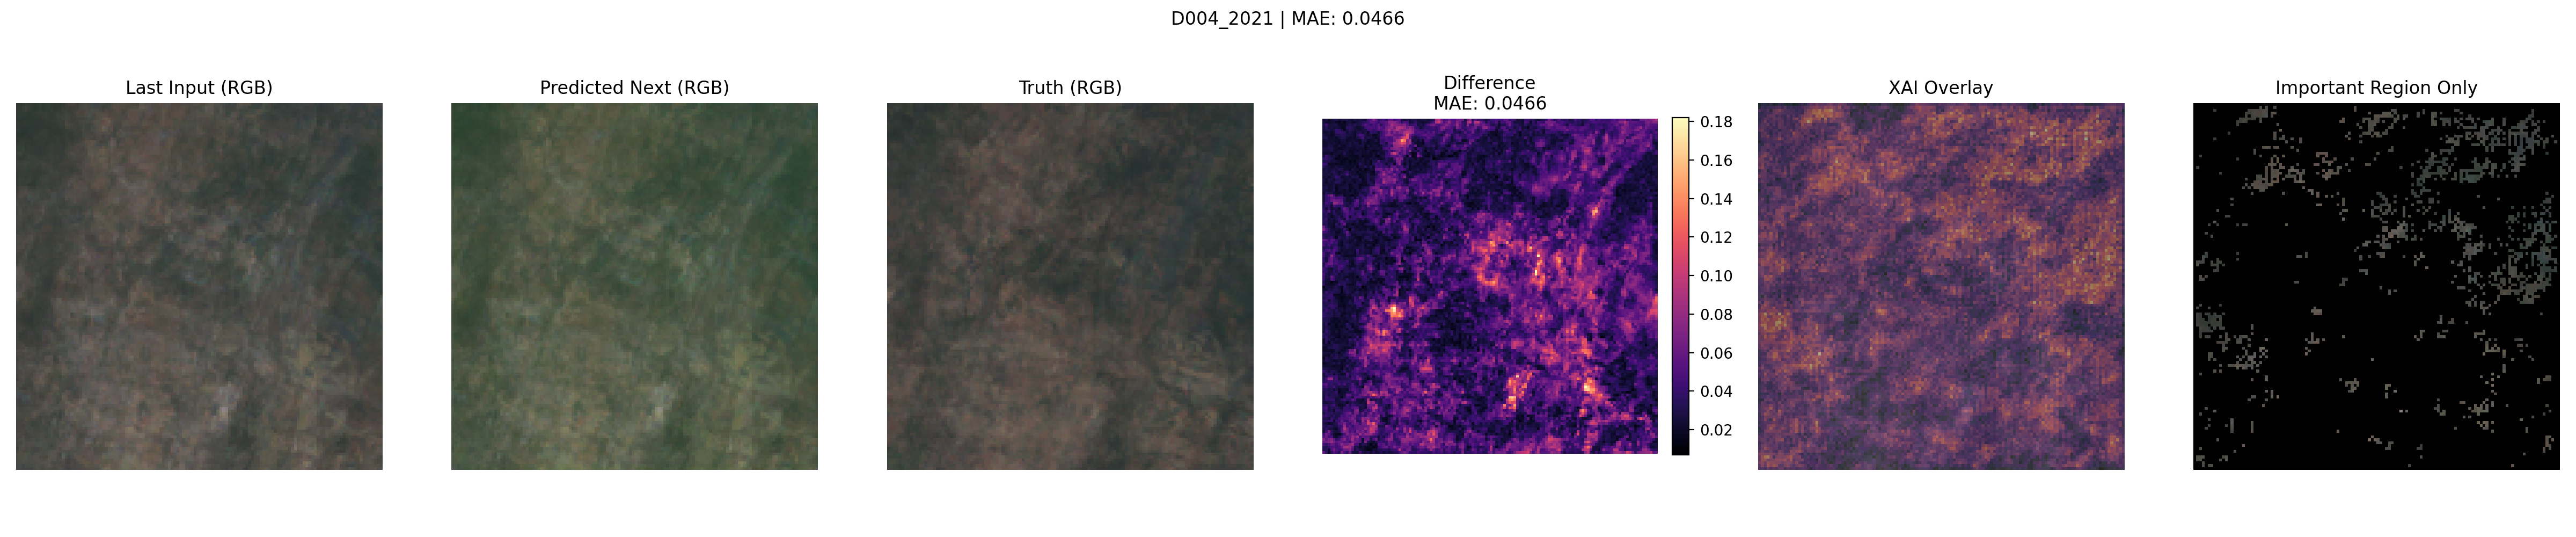

Per-month importance: [0.00881417 0.01634753 0.02023218 0.03946646 0.02991433 0.88522536]
Per-band importance : [0.1011202  0.10221357 0.10306411 0.09763731 0.09989946 0.09857849
 0.10094634 0.0982413  0.09896099 0.09933827]

Running XAI method: ig
Saved XAI visualization → xai_outputs\xai_ig_D004_2021.png


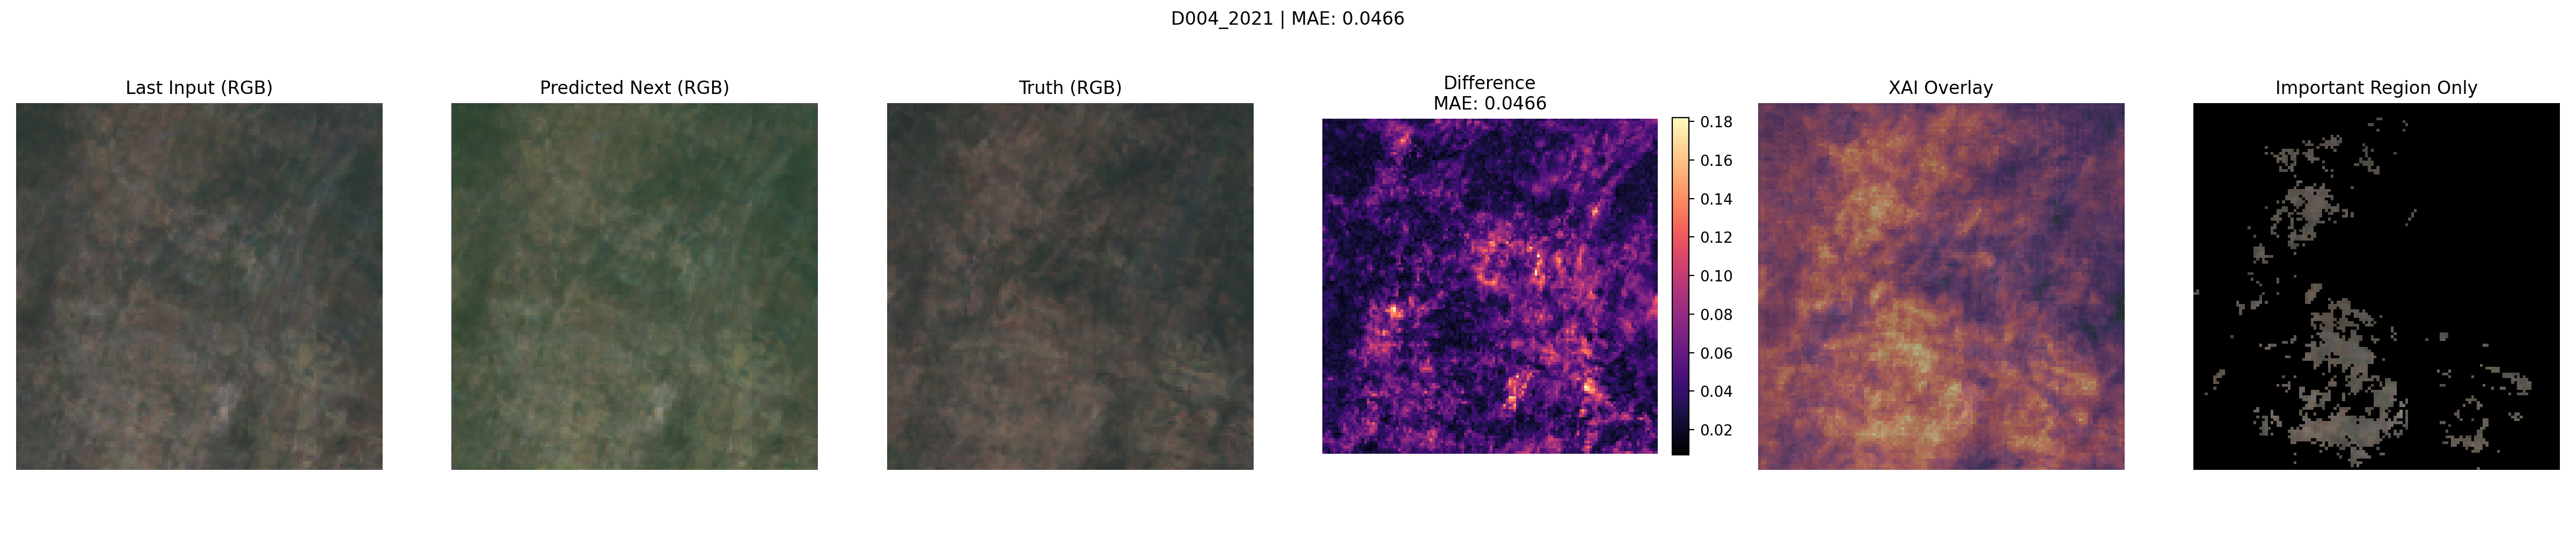

Per-month importance: [0.01777691 0.02785647 0.03271848 0.04651703 0.05815111 0.81698006]
Per-band importance : [0.09167121 0.06476379 0.09959833 0.10376301 0.12952018 0.1305253
 0.11872971 0.02985231 0.11378023 0.11779593]

Running XAI method: occlusion
Saved XAI visualization → xai_outputs\xai_occlusion_D004_2021.png


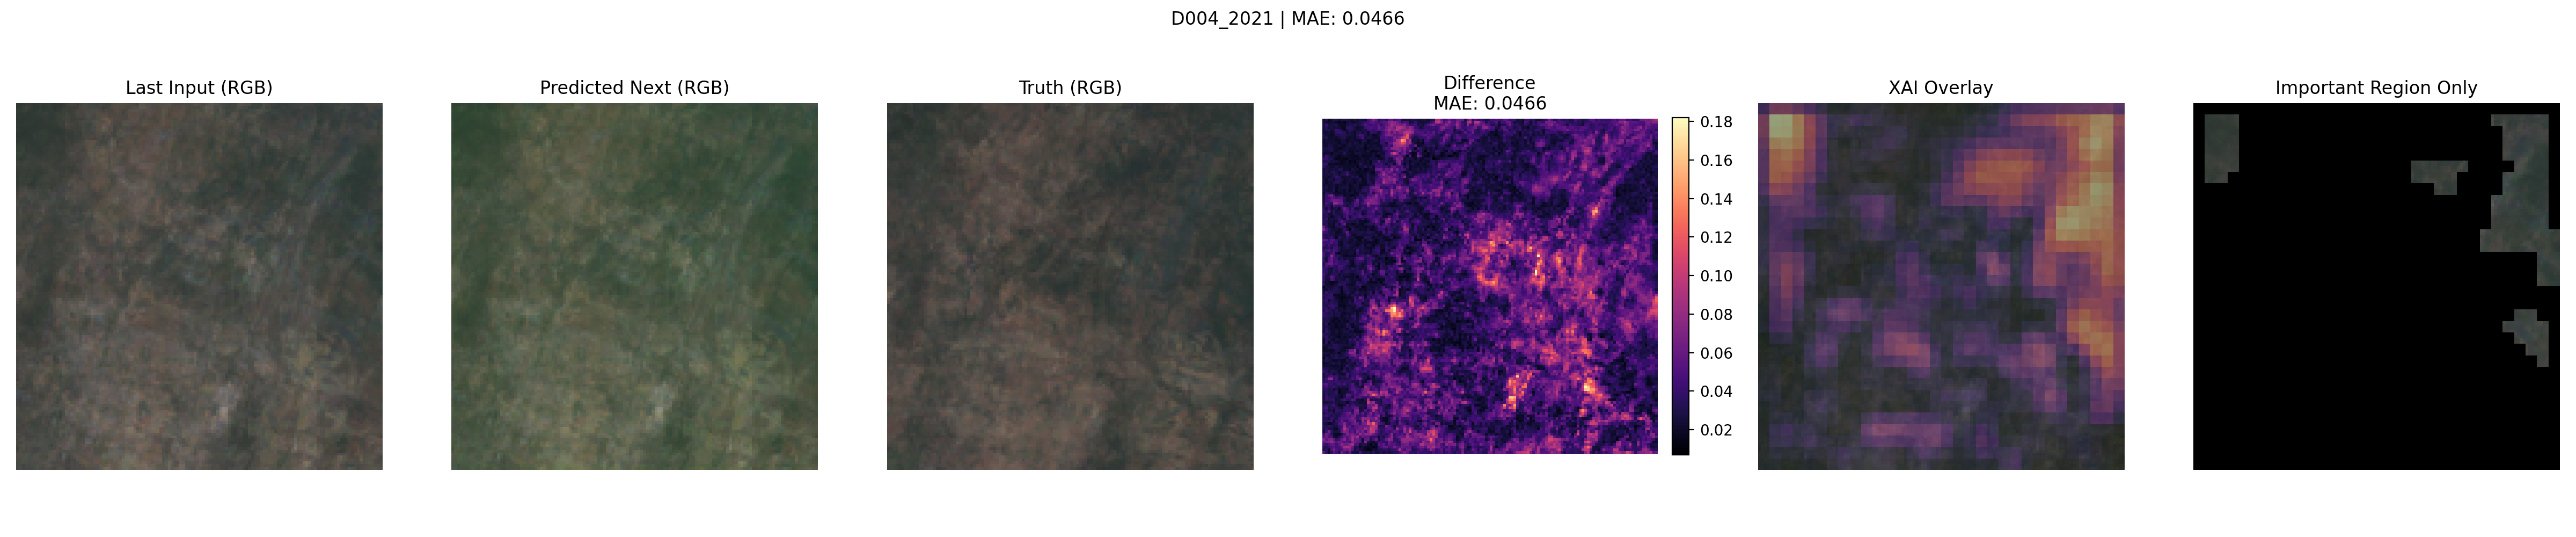

Per-month importance: [4.0574891e-05 8.3593000e-04 8.0757117e-04 1.5348651e-03 4.8096515e-03
 9.9197143e-01]
Per-band importance : [0.08145088 0.01385545 0.19253212 0.16082802 0.02382269 0.03283842
 0.03269927 0.00258148 0.13718466 0.322207  ]

✅ CELL 3 FINISHED


In [16]:
# ------------------------------------------------------------
# 3. RUN ALL XAI METHODS
# ------------------------------------------------------------
for METHOD in ["saliency", "ig", "occlusion"]:

    print("\nRunning XAI method:", METHOD)

    # ------------------------
    # Run XAI
    # ------------------------
    if METHOD == "saliency":
        pred, attr = saliency_xai(model, x, y, xai_cfg)
        pix, per_m, per_b = aggregate_attribution(attr)

    elif METHOD == "ig":
        pred, attr = integrated_gradients_xai(model, x, y, xai_cfg)
        pix, per_m, per_b = aggregate_attribution(attr)

    elif METHOD == "occlusion":
        pred, pix, per_m, per_b = occlusion_xai(model, x, y, xai_cfg)

    else:
        raise ValueError("Unknown XAI method")

    # ------------------------
    # 4. VISUALIZE + SAVE PNG
    # ------------------------
    out_png = f"./xai_outputs/xai_{METHOD}_{zone[0]}.png"

    mae = visualize_xai_rgb(
        x,
        pred,
        y,
        pix,
        xai_cfg,
        out_png,
        zone_name=str(zone[0]),
        show_inline=True,
        apply_stretch=False   # keep reference look
    )

    # ------------------------
    # 5. PRINT RAW IMPORTANCE
    # ------------------------
    if per_m is not None and per_m.sum() > 0:
        print("Per-month importance:", (per_m / per_m.sum()).cpu().numpy())

    if per_b is not None and per_b.sum() > 0:
        print("Per-band importance :", (per_b / per_b.sum()).cpu().numpy())

    # ------------------------------------------------------------
    # 6. CREATE JSON SUMMARY FOR LLM  ✅ (THIS IS WHAT YOU ASKED)
    # ------------------------------------------------------------
    summary = xai_summary_dict(
        zone=zone[0],
        method=METHOD,
        cfg=xai_cfg,
        mae=mae,
        per_m=per_m,
        per_b=per_b,
        pix_attr=pix,
        png_path=out_png,
        topk=25
    )

    out_json = f"./xai_outputs/xai_{METHOD}_{zone[0]}.json"
    save_json(summary, out_json)

    # ------------------------------------------------------------
    # 7. CREATE READY-TO-PASTE LLM PROMPT TEXT
    # ------------------------------------------------------------
    prompt_text = make_llm_prompt(Path(out_json).read_text())

    # out_prompt = f"./xai_outputs/xai_{METHOD}_{zone[0]}_LLM_PROMPT.txt"
    # Path(out_prompt).write_text(prompt_text, encoding="utf-8")

    # print("Saved LLM prompt ->", out_prompt)

    report_text, report_md = run_llm_report_for_xai(
        method=METHOD,
        zone=str(zone[0]),
        png_path=out_png,
        json_path=out_json,
        out_dir="./xai_outputs",
        model_name="gpt-5.1",
    )
    

print("\n✅ CELL 3 FINISHED")

### barcharts

In [17]:
# =========================
# CELL: IMPORTS
# =========================
import json
from pathlib import Path
from typing import Dict, Any, List, Tuple

import numpy as np
import matplotlib.pyplot as plt


In [18]:
# =========================
# CELL: LOAD JSON SUMMARIES
# =========================

def load_xai_json(path: str | Path) -> Dict[str, Any]:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Not found: {p}")
    return json.loads(p.read_text(encoding="utf-8"))

def load_all_xai_jsons(folder: str | Path, pattern: str = "xai_*.json") -> List[Tuple[Path, Dict[str, Any]]]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    items = []
    for p in sorted(folder.glob(pattern)):
        # skip LLM report jsons if they exist
        if "LLM_REPORT" in p.name:
            continue
        try:
            items.append((p, load_xai_json(p)))
        except Exception as e:
            print(f"⚠️ Skipping {p.name}: {e}")
    if not items:
        raise RuntimeError(f"No JSON files matched {pattern} in {folder}")
    return items


In [19]:
# =========================
# CELL: PLOTTING HELPERS (BAR CHARTS)
# =========================

def _to_np_list(x, *, name: str) -> np.ndarray:
    if x is None:
        raise ValueError(f"Missing field: {name}")
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim != 1:
        raise ValueError(f"{name} must be a 1D list/array, got shape {arr.shape}")
    return arr

def plot_month_importance(summary: Dict[str, Any], *, title: str | None = None, top_k: int | None = None):
    per_m = _to_np_list(summary.get("per_month_importance"), name="per_month_importance")
    if per_m.sum() > 0:
        per_m = per_m / per_m.sum()

    labels = [f"M{i+1}" for i in range(len(per_m))]
    if top_k is not None and top_k < len(per_m):
        idx = np.argsort(-per_m)[:top_k]
        per_m = per_m[idx]
        labels = [labels[i] for i in idx]

    plt.figure()
    plt.bar(labels, per_m)
    plt.ylabel("Importance share")
    plt.ylim(0, max(1e-6, float(per_m.max()) * 1.2))
    plt.title(title or "Temporal importance (per month)")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

def plot_band_importance(summary: Dict[str, Any], *, title: str | None = None, top_k: int = 10):
    per_b = _to_np_list(summary.get("per_band_importance"), name="per_band_importance")
    if per_b.sum() > 0:
        per_b = per_b / per_b.sum()

    labels = [f"B{i}" for i in range(len(per_b))]
    if top_k is not None and top_k < len(per_b):
        idx = np.argsort(-per_b)[:top_k]
        per_b = per_b[idx]
        labels = [labels[i] for i in idx]

    plt.figure()
    plt.bar(labels, per_b)
    plt.ylabel("Importance share")
    plt.ylim(0, max(1e-6, float(per_b.max()) * 1.2))
    plt.title(title or f"Spectral importance (top {len(per_b)})")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


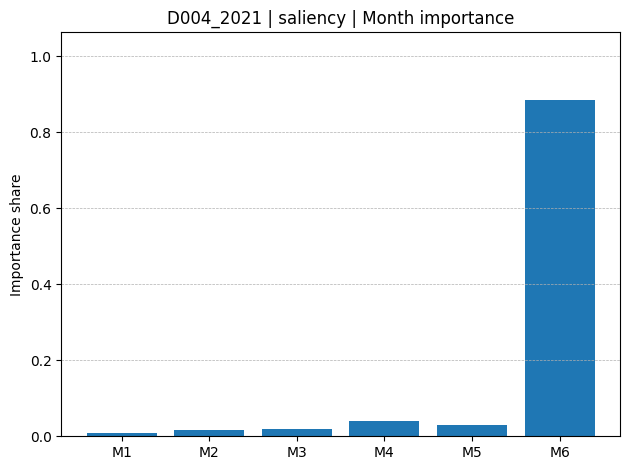

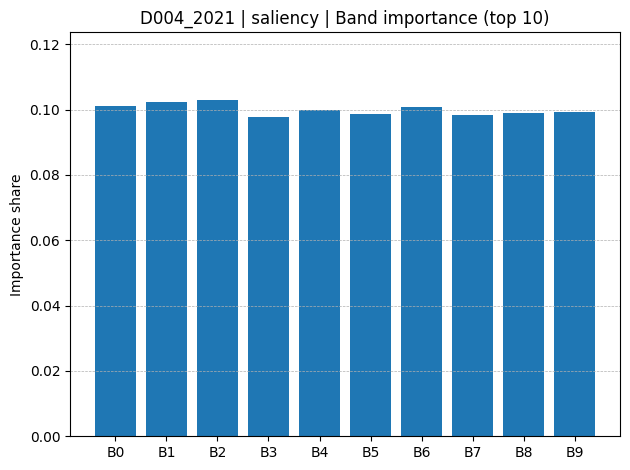

In [20]:
# =========================
# CELL: RUN ON ONE JSON
# =========================

json_path = "./xai_outputs/xai_saliency_D004_2021.json"  # <-- change to your file
summary = load_xai_json(json_path)

method = summary.get("method", "unknown_method")
zone = summary.get("zone", "unknown_zone")
mae = summary.get("metrics", {}).get("mae", None)

plot_month_importance(summary, title=f"{zone} | {method} | Month importance")
plot_band_importance(summary, title=f"{zone} | {method} | Band importance (top 10)", top_k=10)


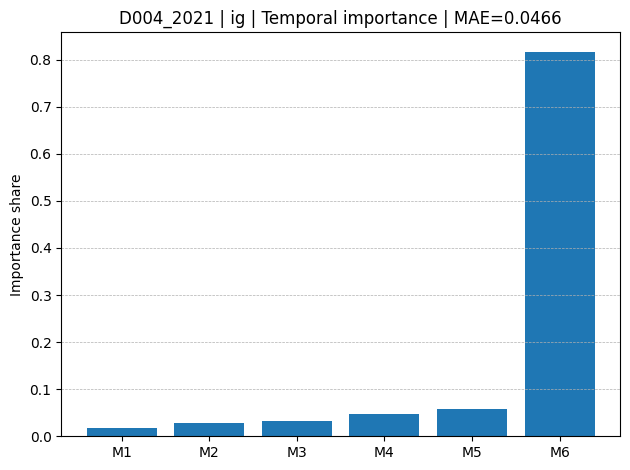

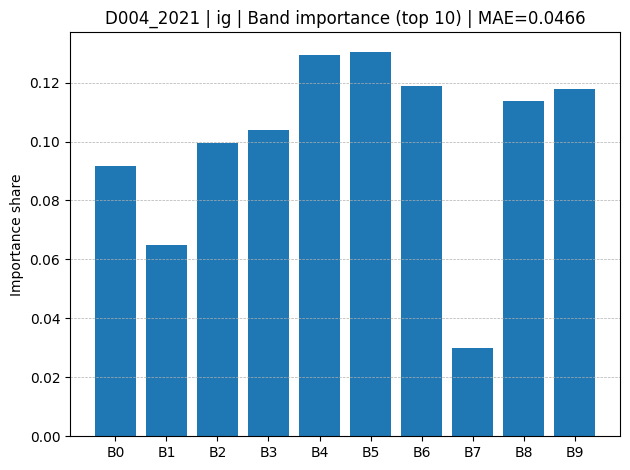

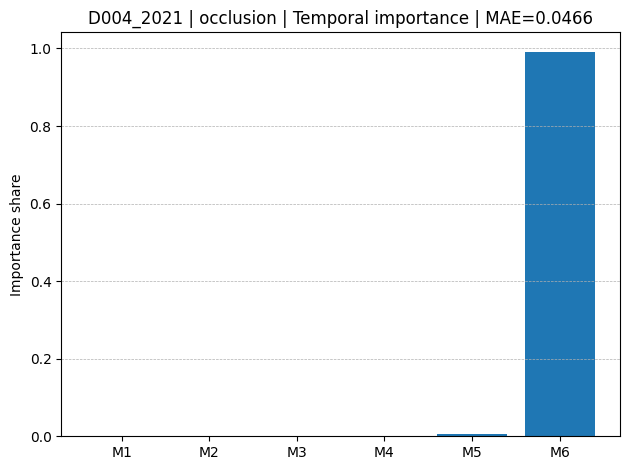

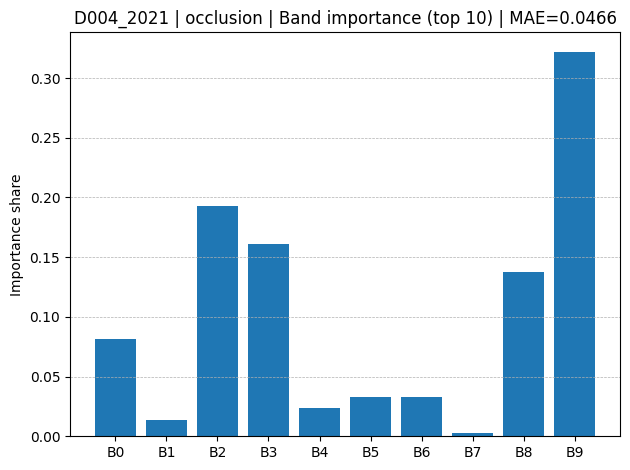

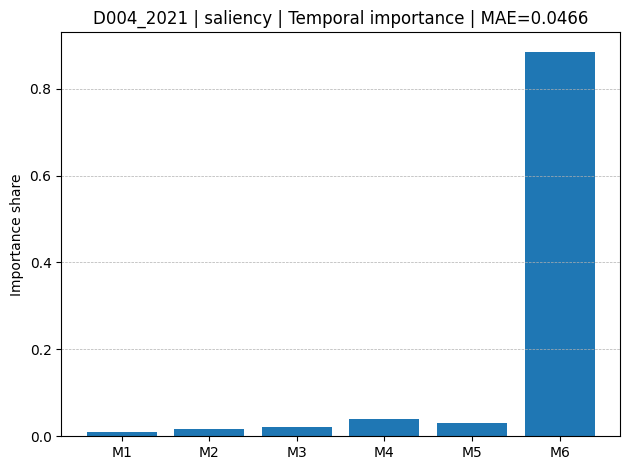

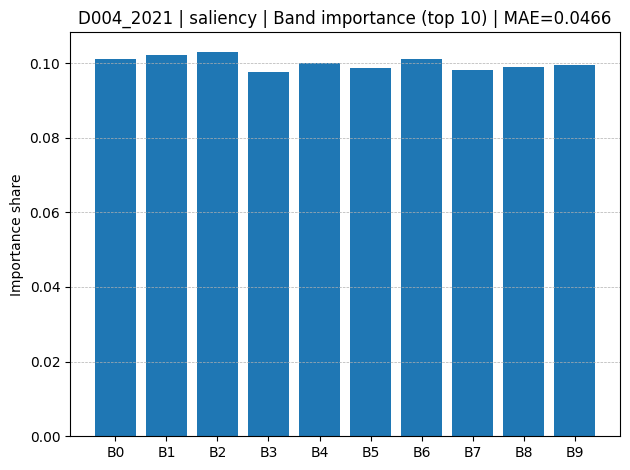

✅ Saved plots in: D:\Amrita\Final Year Project\chaklu approach\xai_outputs\plots


In [21]:
# =========================
# CELL: RUN ON ALL JSONs IN A FOLDER
#   - Makes month + band bar charts for every summary
#   - Optionally saves images to disk
# =========================

def plot_and_optionally_save_all(
    xai_folder: str | Path = "./xai_outputs",
    save: bool = True,
    out_folder: str | Path = "./xai_outputs/plots",
    band_top_k: int = 10
):
    items = load_all_xai_jsons(xai_folder, pattern="xai_*.json")
    out_folder = Path(out_folder)
    if save:
        out_folder.mkdir(parents=True, exist_ok=True)

    for p, summary in items:
        method = summary.get("method", p.stem)
        zone = summary.get("zone", "zone")
        mae = summary.get("metrics", {}).get("mae", None)
        mae_str = f" | MAE={mae:.4f}" if isinstance(mae, (int, float)) else ""

        # --- months ---
        per_m = np.asarray(summary.get("per_month_importance", []), dtype=np.float32)
        if per_m.size > 0:
            if per_m.sum() > 0:
                per_m = per_m / per_m.sum()
            labels_m = [f"M{i+1}" for i in range(len(per_m))]

            plt.figure()
            plt.bar(labels_m, per_m)
            plt.ylabel("Importance share")
            plt.title(f"{zone} | {method} | Temporal importance{mae_str}")
            plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
            plt.tight_layout()
            if save:
                out_path = out_folder / f"{zone}_{method}_months.png"
                plt.savefig(out_path, dpi=200)
            plt.show()
            plt.close()

        # --- bands ---
        per_b = np.asarray(summary.get("per_band_importance", []), dtype=np.float32)
        if per_b.size > 0:
            if per_b.sum() > 0:
                per_b = per_b / per_b.sum()

            labels_b = [f"B{i}" for i in range(len(per_b))]
            if band_top_k is not None and band_top_k < len(per_b):
                idx = np.argsort(-per_b)[:band_top_k]
                per_b = per_b[idx]
                labels_b = [labels_b[i] for i in idx]

            plt.figure()
            plt.bar(labels_b, per_b)
            plt.ylabel("Importance share")
            plt.title(f"{zone} | {method} | Band importance (top {len(per_b)}){mae_str}")
            plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
            plt.tight_layout()
            if save:
                out_path = out_folder / f"{zone}_{method}_bands_top{len(per_b)}.png"
                plt.savefig(out_path, dpi=200)
            plt.show()
            plt.close()

    if save:
        print(f"✅ Saved plots in: {out_folder.resolve()}")

# Run
plot_and_optionally_save_all(
    xai_folder="./xai_outputs",
    save=True,
    out_folder="./xai_outputs/plots",
    band_top_k=10
)
